# 07 - SPH exploratory data analysis

SPH is the Shandong Provincial Hospital ECG database (Liu et al., *Scientific Data* 2022): 25,770 twelve-lead
resting ECGs of 24,666 patients recorded between August 2019 and August 2020, at 500 Hz and 10 to 60 s long.
Cardiologists described each ECG with **AHA standard statement codes**, where a `+` adds a modifier such as
"frequent" or "old". This notebook describes the dataset: missing and repeated values, what the labels mean
and how they relate to age and sex, and what the stored signals contain.

The release is read from `data/raw/sph/` after checking every file against the download manifest's MD5.
The analysis code is in `ecg_experiment/eda/sph.py`.

In [1]:
import sys
from pathlib import Path

ROOT = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / "pyproject.toml").exists())
sys.path.insert(0, str(ROOT))

In [2]:
import json

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from ecg_experiment.ecg_quality import EXCLUSION_REASONS, REVIEW_FLAGS
from ecg_experiment.eda import sph
from ecg_experiment.eda.cross import combined_summary
from ecg_experiment.eda.signals import plot_ecg, problem_counts
from ecg_experiment.eda.stats import age_band, odds_ratios, plot_prevalence, prevalence
from ecg_experiment.sph import SUPERCLASSES, duplicate_status

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)
sns.set_theme(style="whitegrid")

meta = sph.load_metadata()
summary = sph.sph_summary(meta)
quality = sph.window_quality(meta)
print(f"{len(meta):,} ECGs, {meta['patient_id'].nunique():,} patients")

25,770 ECGs, 24,666 patients


## 1. Missing values, patients and recording length

,value
ECGs,25770
patients,24666
missing values in the table,0
patients with more than one ECG,1066
most ECGs for one patient,5
male share,0.554
median age,50.0
age range,18-95
first and last date,2019-08-01 to 2020-08-31


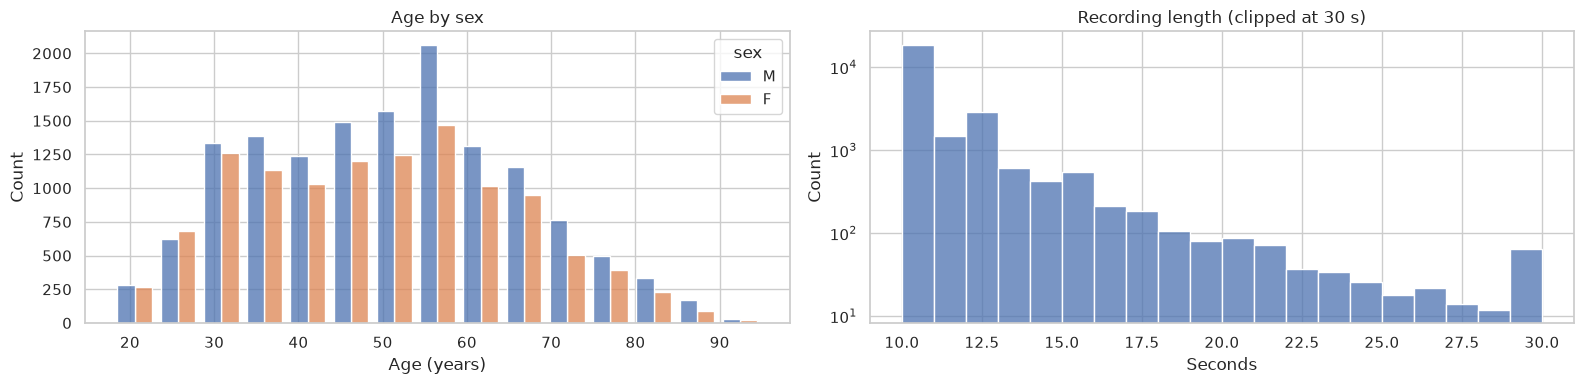

,count,mean,std,min,50%,73%,90%,99%,max
seconds,25770.0,10.9,2.4,10.0,10.0,10.0,12.0,21.0,56.0


In [3]:
per_patient = meta.groupby("patient_id").size()
display(pd.Series({
    "ECGs": len(meta),
    "patients": meta["patient_id"].nunique(),
    "missing values in the table": int(meta[["patient_id", "age", "sex", "AHA_Code"]].isna().sum().sum()),
    "patients with more than one ECG": int((per_patient > 1).sum()),
    "most ECGs for one patient": int(per_patient.max()),
    "male share": (meta["sex"] == "M").mean().round(3),
    "median age": meta["age"].median(),
    "age range": f"{meta['age'].min()}-{meta['age'].max()}",
    "first and last date": f"{meta['date'].min():%Y-%m-%d} to {meta['date'].max():%Y-%m-%d}",
}).to_frame("value"))
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
sns.histplot(meta, x="age", hue="sex", binwidth=5, multiple="dodge", shrink=0.8, ax=axes[0])
axes[0].set(title="Age by sex", xlabel="Age (years)")
sns.histplot(meta["duration_s"].clip(upper=30), binwidth=1, ax=axes[1])
axes[1].set(title="Recording length (clipped at 30 s)", xlabel="Seconds", yscale="log")
plt.tight_layout()
plt.show()
display(meta["duration_s"].describe(percentiles=[0.5, 0.73, 0.9, 0.99]).round(1).to_frame("seconds").T)

**Finding: a complete table, mostly one ECG per patient, mostly ten seconds.**

- No value is missing: every ECG has a patient, age, sex and at least one code. Ages run from 18 to 95 with no
  placeholders (median 50), and 55.4% of ECGs are from men.
- 1,066 patients (4.3%) have more than one ECG, at most five, so patients and ECGs are almost the same unit.
- Every recording is at least 10 s long. The median and the 73rd percentile are exactly 10 s; 10% are longer
  than 12 s and the longest is 56 s. A ten-second window is available for every ECG.

## 2. Labels

Each ECG lists one or more AHA codes. What do the codes say, and how are "normal" ECGs coded?

In [4]:
codes = sph.code_counts(meta)
display(codes.head(25).round(4))
coded_with_normal = meta[meta["codes"].apply(lambda values: "1" in values)]
display(pd.Series({
    "ECGs with code 1 (normal ECG)": len(coded_with_normal),
    "... of which have any other code": int(coded_with_normal["codes"].apply(len).gt(1).sum()),
    "ECGs whose codes are only sinus rhythm variants (21, 22, 23)": int(meta["sinus_variant_only"].sum()),
    "codes in the dictionary never used": len(sph.load_codes().query("Category != 'Modifier'").index
                                              .difference(codes.index)),
}).to_frame("ECGs"))

,records,description,category,label_group,share
codes,,,,,
1,13905,Normal ECG,A,normal,0.5396
22,2711,Sinus bradycardia,C,ignored,0.1052
147,2218,T-wave abnormality,L,STTC,0.0861
145,1829,ST deviation,L,STTC,0.0710
23,1553,Sinus arrhythmia,C,ignored,0.0603
105,1259,Incomplete right bundle-branch block,I,CD,0.0489
60,1067,Ventricular premature complex(es),F,ignored,0.0414
146,1063,ST deviation with T-wave change,L,STTC,0.0412
21,725,Sinus tachycardia,C,ignored,0.0281


,ECGs
ECGs with code 1 (normal ECG),13905
... of which have any other code,0
"ECGs whose codes are only sinus rhythm variants (21, 22, 23)",2824
codes in the dictionary never used,0


**Finding: "normal" is an exclusive code.** Code `1` (normal ECG) appears on 13,905 ECGs (54%) and is
never combined with any other code. An otherwise normal ECG with a sinus rhythm variant is therefore coded
with the rhythm alone: 2,824 ECGs carry only sinus bradycardia, tachycardia or arrhythmia. In PTB-XL, such an
ECG would usually be "NORM" plus a rhythm statement. The most common findings are sinus bradycardia (10.5%),
T-wave abnormality (8.6%), ST deviation (7.1%) and sinus arrhythmia (6.0%). Every code in the dictionary is
used at least once.

In [5]:
labels = pd.DataFrame({
    "primary label": meta["primary"].map({0: "negative (normal)", 1: "positive"}).fillna("undefined"),
    "secondary label": meta["secondary"].map({0: "negative (normal)", 1: "positive"}).fillna("undefined"),
})
display(pd.concat([labels[column].value_counts().rename(column) for column in labels], axis=1))
display(meta[list(SUPERCLASSES)].sum().rename("ECGs").to_frame().T)
undefined = meta[meta["primary"].isna() & ~meta["sinus_variant_only"]]
display(undefined["codes"].explode().value_counts().head(8).rename("ECGs among the other undefined")
        .to_frame().join(codes["description"]))

,primary label,secondary label
negative (normal),13905,16729
positive,7260,7260
undefined,4605,1781


,MI,STTC,CD,HYP
ECGs,260.0,5090.0,2395.0,229.0


,ECGs among the other undefined,description
codes,,
60,664,Ventricular premature complex(es)
30,314,Atrial premature complex(es)
50,285,Atrial fibrillation
125,238,Low voltage
120,135,Right-axis deviation
22,131,Sinus bradycardia
121,108,Left-axis deviation
23,69,Sinus arrhythmia


**Finding: the standard label is defined for 82% of ECGs.** Mapping the codes to the PTB-XL
superclasses (as in Experiment 022) gives 13,905 negatives, 7,260 positives and 4,605 undefined ECGs. Counting
sinus-variant-only ECGs as negative (the secondary label) leaves 1,781 undefined. The positives are mostly
repolarization findings (STTC, 5,090 ECGs) and conduction disorders (CD, 2,395); myocardial infarction (260)
and hypertrophy (229) are rare. The remaining undefined ECGs have only rhythm or form findings, most often
ventricular premature complexes (664), atrial premature complexes (314), atrial fibrillation (285) and low
voltage (238).

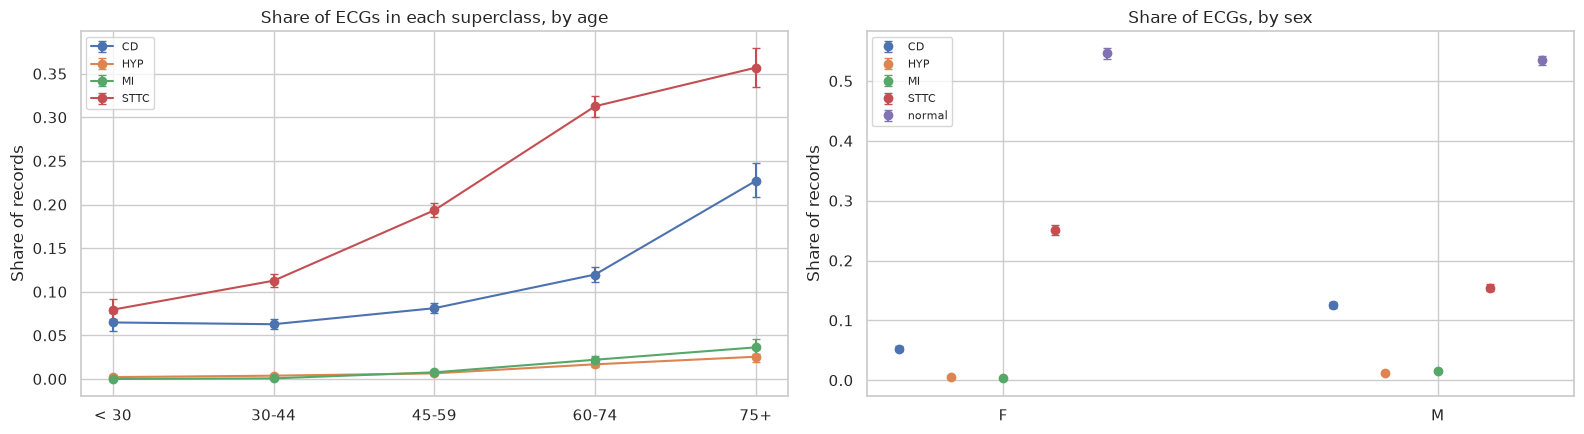

age_band,< 30,30-44,45-59,60-74,75+
records,2315.000,7438.000,8540.000,5712.000,1765.000
prevalence,0.578,0.665,0.572,0.393,0.283


,outcome,predictor,odds_ratio,lower,upper,p_value
0,MI,age per 10 years,1.988,1.821,2.170,0.000
1,MI,male,5.250,3.637,7.580,0.000
2,STTC,age per 10 years,1.486,1.455,1.517,0.000
3,STTC,male,0.495,0.464,0.528,0.000
4,CD,age per 10 years,1.324,1.288,1.361,0.000
5,CD,male,2.524,2.292,2.779,0.000
6,HYP,age per 10 years,1.604,1.471,1.749,0.000
7,HYP,male,1.848,1.388,2.462,0.000
8,normal,age per 10 years,0.746,0.733,0.758,0.000
9,normal,male,0.991,0.943,1.043,0.738


In [6]:
meta["age_band"] = age_band(meta["age"])
meta["male"] = meta["sex"] == "M"
for name in SUPERCLASSES:
    meta[name] = meta[name].astype(bool)
meta["normal"] = meta["primary"] == 0
outcomes = [*SUPERCLASSES, "normal"]
fig, axes = plt.subplots(1, 2, figsize=(16, 4.5))
plot_prevalence(prevalence(meta, "age_band", list(SUPERCLASSES)), "age_band", axes[0],
                "Share of ECGs in each superclass, by age")
plot_prevalence(prevalence(meta, "sex", outcomes), "sex", axes[1], "Share of ECGs, by sex", connect=False)
plt.tight_layout()
plt.show()
display(prevalence(meta, "age_band", ["normal"]).set_index("age_band")[["records", "prevalence"]].round(3).T)
display(odds_ratios(meta, outcomes).round(3))

**Finding: abnormal findings follow age, and differ by sex.**

- The share of normal ECGs is 58-67% under 45 and falls to 39% at 60-74 and 28% at 75 and over (odds 0.75 per
  decade). It does not differ by sex (odds ratio 0.99, p = 0.74).
- Every superclass becomes more common with age: STTC rises from about 8% under 30 to about 36% at 75 and
  over, and CD from about 6% to about 23%.
- The sexes differ in opposite directions: after adjusting for age, men have 5.3 times the odds of an MI
  statement, 2.5 times the odds of CD and 1.8 times the odds of HYP, but half the odds of STTC (0.50). STTC
  statements are on 25% of women's ECGs and 15% of men's.

## 3. Repeated recordings

Some patients have more than one ECG. Are any of them the same recording stored twice?

In [7]:
status = duplicate_status(quality["signal_sha256"], meta["AHA_Code"].reindex(quality.index))
groups = meta.join(quality[["signal_sha256"]])[quality["signal_sha256"].duplicated(keep=False)]
by_group = groups.groupby("signal_sha256")
display(pd.Series({
    "groups of identical first-10-s windows": by_group.ngroups,
    "ECGs in them": len(groups),
    "groups with more than two copies": int((by_group.size() > 2).sum()),
    "groups from one patient": int(by_group["patient_id"].nunique().eq(1).sum()),
    "groups recorded on one date": int(by_group["date"].nunique().eq(1).sum()),
    "groups whose copies have different codes": int(by_group["AHA_Code"].nunique().gt(1).sum()),
    "groups whose copies disagree on the primary label": int(by_group["primary"].nunique(dropna=False)
                                                             .gt(1).sum()),
}).to_frame("count"))
repeat = meta[meta["ecgs_of_patient"] > 1]
print(f"Patients with several ECGs: {repeat['patient_id'].nunique():,}; "
      f"their ECGs recorded on one date: {repeat.groupby('patient_id')['date'].nunique().eq(1).mean():.1%}")
conflicts = groups[groups["signal_sha256"].map(by_group["AHA_Code"].nunique()) > 1]
display(conflicts.sort_values("signal_sha256")[["patient_id", "AHA_Code"]].head(10))

,count
groups of identical first-10-s windows,168
ECGs in them,336
groups with more than two copies,0
groups from one patient,168
groups recorded on one date,168
groups whose copies have different codes,25
groups whose copies disagree on the primary label,10


Patients with several ECGs: 1,066; their ECGs recorded on one date: 18.2%


,patient_id,AHA_Code
ecg_id,,
A03312,S03278,146
A11600,S03278,147
A13218,S12901,145+362
A22708,S12901,1
A12132,S11872,105
A18920,S11872,1
A09784,S09610,106;60+308;82
A13474,S09610,106;60+308
A15065,S14658,50;146


**Finding: 168 recordings are stored twice, and 10 of the pairs disagree on the label.**

- 168 pairs of ECGs (336 records) have bit-identical first ten seconds; no recording appears more than twice.
  Every pair belongs to one patient and one date, so these are duplicate uploads, not repeat recordings.
- In 25 pairs the two copies carry different codes, and in 10 pairs one copy is normal or undefined while the
  other is abnormal (for example `145+362`, ST depression, versus `1`, normal). The same signal was read twice
  with different conclusions. This is a direct view of reader disagreement in the labels.
- Real repeat recordings are different: among the 1,066 patients with several ECGs, 18.2% have all of them
  on one date.

## 4. Signal integrity

The same checks as for the other sources: missing samples, constant or flat leads, amplitude, and whether the
limb leads obey Einthoven's law (III = II - I, aVR = -(I + II) / 2), computed on the full recordings.

,ECGs
records,25770
any_nan,0
fully_constant_lead,0
lead_flat_for_1s,2
lead_over_10mv,323
limb_identity_violated,195
heart_rate_not_estimated,21


,count,mean,std,min,1%,50%,99%,99.9%,max
peak_abs_mv,25770.0,3.041,28.184,0.576,0.877,1.741,15.117,353.098,1590.000
std,25770.0,0.151,0.999,0.042,0.069,0.128,0.297,1.539,122.613
einthoven_residual,25770.0,0.004,0.042,0.000,0.002,0.002,0.002,0.829,1.500
heart_rate,25749.0,73.856,13.928,12.262,48.387,72.115,119.048,157.068,180.723


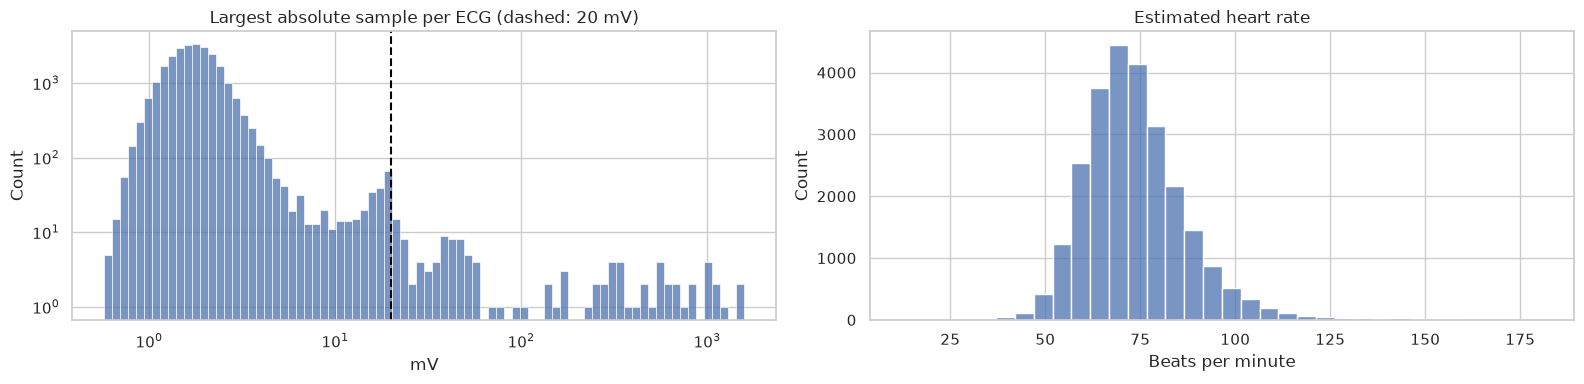

In [8]:
display(problem_counts(summary).to_frame("ECGs"))
display(summary[["peak_abs_mv", "std", "einthoven_residual", "heart_rate"]]
        .describe(percentiles=[0.01, 0.5, 0.99, 0.999]).round(3).T)
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
sns.histplot(summary["peak_abs_mv"], log_scale=True, bins=80, ax=axes[0])
axes[0].axvline(20, color="black", linestyle="--")
axes[0].set(title="Largest absolute sample per ECG (dashed: 20 mV)", xlabel="mV", yscale="log")
sns.histplot(summary["heart_rate"].dropna(), binwidth=5, ax=axes[1])
axes[1].set(title="Estimated heart rate", xlabel="Beats per minute")
plt.tight_layout()
plt.show()

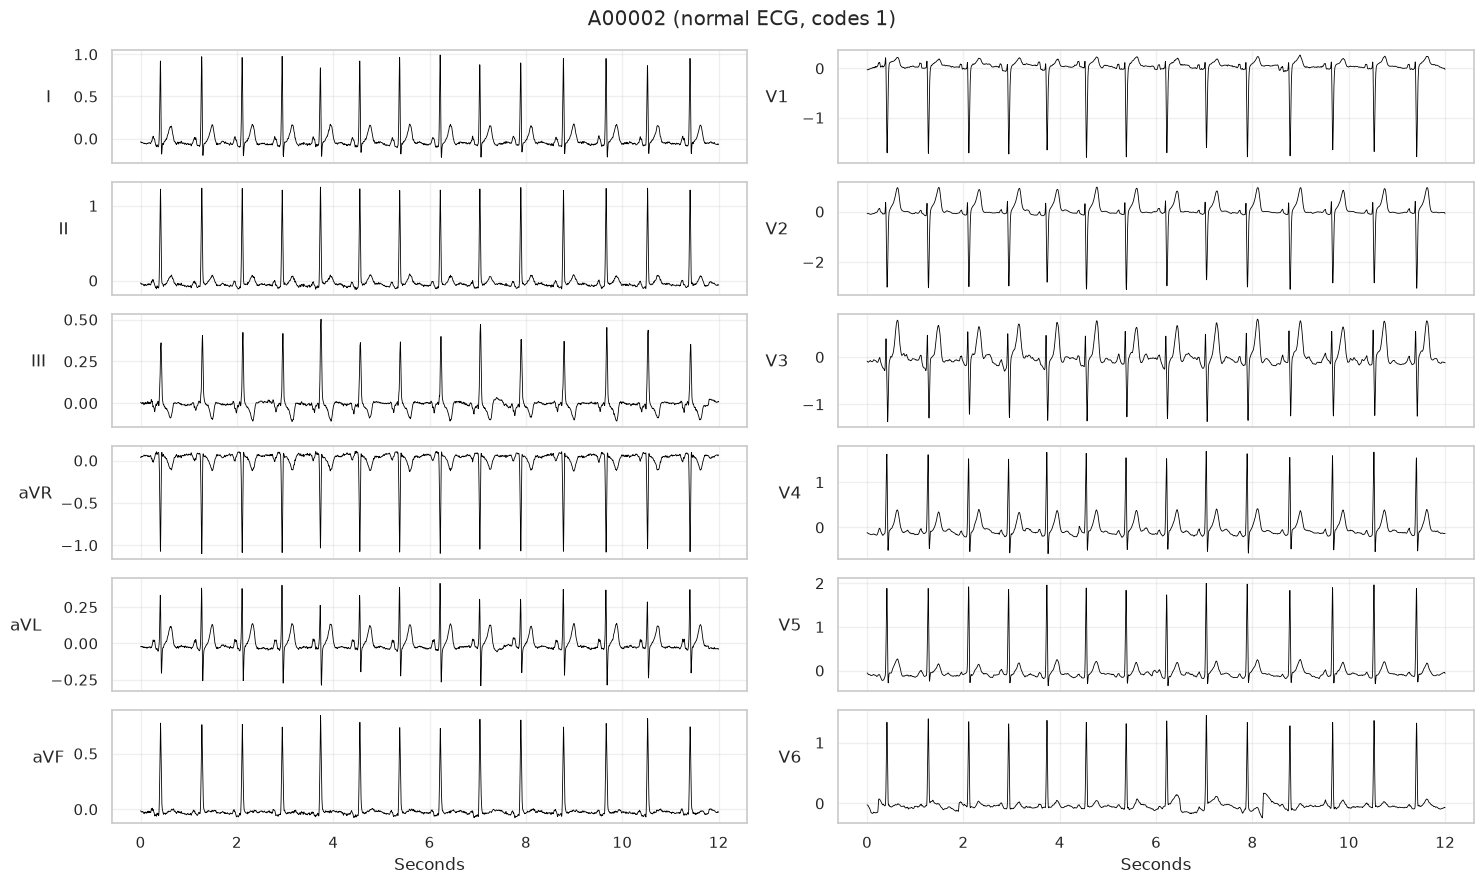

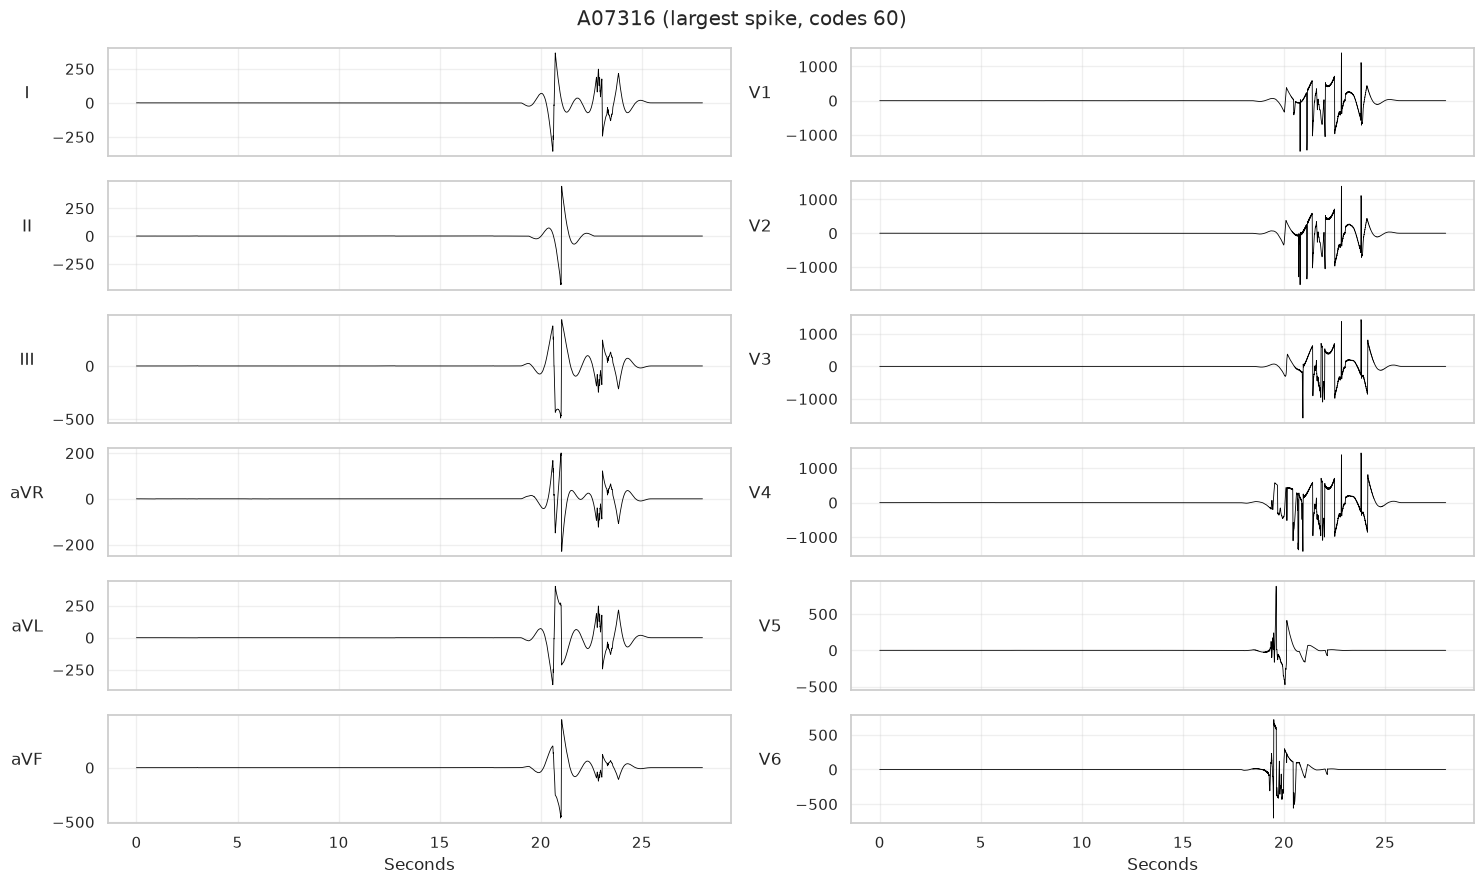

,value
ECGs violating a limb identity by over 0.05 mV,133.000000
... of which also have a sample over 20 mV,16.000000
median Einthoven residual (mV),0.001709
ECGs with a sample over 20 mV anywhere,123.000000
... of which inside the first 10 s,98.000000


In [9]:
spike = summary["peak_abs_mv"].idxmax()
normal_example = meta.index[(meta["primary"] == 0)][0]
for ecg_id, title in ((normal_example, "normal ECG"), (spike, "largest spike")):
    signal, fs = sph.read_signal(ecg_id)
    codes = meta.loc[ecg_id, "AHA_Code"]
    plot_ecg(signal, fs, f"{ecg_id} ({title}, codes {codes})", seconds=len(signal) / fs)
    plt.show()
limb_bad = summary["einthoven_residual"] > 0.05
display(pd.Series({
    "ECGs violating a limb identity by over 0.05 mV": int(limb_bad.sum()),
    "... of which also have a sample over 20 mV": int((limb_bad & (summary["peak_abs_mv"] > 20)).sum()),
    "median Einthoven residual (mV)": summary["einthoven_residual"].median(),
    "ECGs with a sample over 20 mV anywhere": int((summary["peak_abs_mv"] > 20).sum()),
    "... of which inside the first 10 s": int((quality["adc_rail"] | quality["extreme_amplitude"]).sum()),
}).to_frame("value"))

**Finding: clean signals, apart from a small group of huge artifacts.**

- No sample is missing, no lead is constant, and only 2 ECGs have a lead flat for a second.
- The limb leads obey Einthoven's law to 0.0017 mV (median), which is the rounding of the stored float16
  values: the leads are in the standard order and in mV. 133 ECGs violate it by more than 0.05 mV, 16 of
  which also contain a sample over 20 mV.
- Amplitudes are ordinary (median largest sample 1.74 mV, 99th percentile 15.1 mV), but the top 0.1% reach
  353 mV and the maximum is 1,590 mV. 123 ECGs have a sample over 20 mV, 98 of them inside the first ten
  seconds. The largest example is an ordinary ECG for about 19 s followed by a burst of deflections of more
  than 1,000 mV in every lead, which cannot be cardiac.
- The estimated heart rate has a median of 72 beats per minute; it could not be estimated for 21 ECGs.

## 5. How the signals were filtered

Sources differ in how much low-frequency (baseline wander, below 0.7 Hz), mains (50 Hz) and high-frequency
(above 40 Hz) power their signals keep. This is a fingerprint of the recording and export chain, not of the
heart. How does SPH compare with the other sources?

,std,baseline_fraction,powerline_50_fraction,high_frequency_fraction,heart_rate
source,,,,,
sph,0.12837,0.00057,0.00024,0.00324,72.11538
cpsc_2018_extra,0.14352,0.00600,0.00049,0.00498,76.62835
cpsc_2018,0.14932,0.00652,0.00054,0.00550,76.92308
mimic,0.13260,0.00830,0.00099,0.01121,74.62687
ptbxl,0.15245,0.01990,0.00071,0.00663,71.25891
code15,0.31570,0.02289,0.00011,0.00140,71.00592
chapman_shaoxing,0.15089,0.02320,0.00119,0.01217,73.52941
georgia,0.14328,0.02385,0.00082,0.00790,75.28231


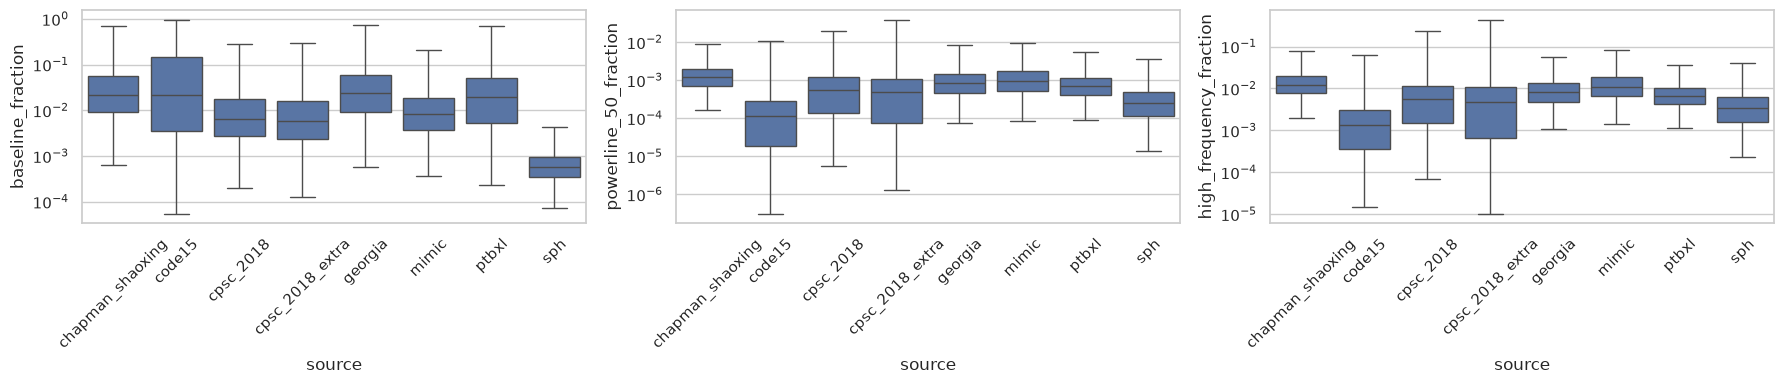

In [10]:
others = combined_summary()
columns = ["std", "baseline_fraction", "powerline_50_fraction", "high_frequency_fraction", "heart_rate"]
table = pd.concat([others[["source", *columns]], summary[columns].assign(source="sph")])
display(table.groupby("source")[columns].median().round(5).sort_values("baseline_fraction"))
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
sample = table.groupby("source").sample(3000, random_state=0).reset_index(drop=True)
for axis, column in zip(axes, ["baseline_fraction", "powerline_50_fraction", "high_frequency_fraction"],
                        strict=True):
    sns.boxplot(sample, x="source", y=column, log_scale=True, showfliers=False, ax=axis)
    axis.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

**Finding: SPH is the most heavily filtered source.** Its median share of power below 0.7 Hz is
0.00057, 35 times less than PTB-XL (0.0199) and 10 times less than CPSC-Extra (0.0060), the next lowest. It
also keeps less 50 Hz mains power and less high-frequency power than every source except CODE-15. Its median lead amplitude (0.128 mV standard deviation) is 16% lower than PTB-XL's (0.152 mV). The
signals were therefore band-pass filtered before release: baseline wander and noise are almost absent. A model
trained on less filtered sources sees a systematically smoother signal here, which is a recording-chain
difference, not a cardiac one.

## 6. The project quality policy on SPH

The quality policy of `ecg_experiment/ecg_quality.py` scores a ten-second window. It is applied here to the
first 10 s of each ECG, which is the window the project would use.

In [11]:
display(quality[[*EXCLUSION_REASONS, *REVIEW_FLAGS, "excluded"]].sum().rename("ECGs").to_frame().T)
scored = quality.join(meta[["primary"]])
display(scored.groupby("excluded")["primary"].agg(["size", "mean"]).round(3)
        .rename(columns={"size": "ECGs", "mean": "positive share of labeled"}))

,nonfinite,constant_lead,flat_segment,adc_rail,extreme_amplitude,near_flat_record,noise_dominated,amplitude_over_10mv,limb_identity_violated,strong_baseline_wander,excluded
ECGs,0,0,0,64,34,0,0,290,117,1,98


,ECGs,positive share of labeled
excluded,,
False,25672,0.343
True,98,0.221


**Finding: the policy removes 98 ECGs, all for amplitude.** In the first ten seconds, 64 ECGs
reach the rail rule (32.6 mV or more) and 34 the extreme-amplitude rule (over 20 mV). In SPH these are not ADC
rail values but the huge artifacts of section 4. No ECG fails the flat, constant, near-flat or noise rules.
Among the review flags, 290 ECGs have a sample over 10 mV, 117 violate a limb identity and 1 has strong
baseline wander. The excluded ECGs are less often abnormal (22.1% of those with a defined label, against
34.3%), so removing them does not remove hard positive cases.

## 7. The clean SPH manifest

`scripts/data/build_sph_clean.py` publishes `data/processed/sph_clean_v1/`: one row per ECG with its labels,
quality result and duplicate status. No waveform is copied.

In [12]:
clean_metadata = json.loads((ROOT / "data/processed/sph_clean_v1/metadata.json").read_text())
display(pd.DataFrame({name: clean_metadata[name]["primary"] | {"records": clean_metadata[name]["records"]}
                      for name in ("evaluation", "training")}))
display(pd.Series(clean_metadata["duplicate_status"]).rename("ECGs").to_frame().T)

,evaluation,training
0.0,13818,13758
1.0,7190,7173
nan,4569,4548
records,25577,25479


,dropped_conflict,dropped_copy,kept,unique
ECGs,50,143,143,25434


**Finding.** The manifest keeps one copy of each duplicate pair whose copies agree (143 kept,
143 dropped) and drops both copies of the 25 conflicting pairs (50 ECGs). The evaluation set keeps
policy-excluded ECGs, as the policy prescribes for held-out data: 25,577 ECGs, of which 13,818 negative,
7,190 positive and 4,569 undefined. The training set also removes the policy exclusions: 25,479 ECGs, of
which 13,758 negative, 7,173 positive and 4,548 undefined.

## 8. Conclusions about the dataset

- **Format.** One consistent format: 500 Hz, mV, standard lead order, at least ten seconds per ECG. The table
  has no missing values, and almost every patient has one ECG.
- **Labels.** Cardiologist AHA codes, with an exclusive "normal ECG" code. A standard binary label is defined
  for 82% of ECGs (93% if sinus-variant-only ECGs count as normal). Abnormal findings are dominated by
  repolarization and conduction statements; infarction and hypertrophy are rare.
- **Age and sex.** Abnormality rises with age as in the other sources. STTC is more common in women, and MI,
  CD and HYP in men.
- **Problems.** 168 duplicate uploads, 25 of them with conflicting codes, and about 120 ECGs with huge
  non-cardiac artifacts. Both are handled by `data/processed/sph_clean_v1`.
- **Filtering.** SPH signals were band-pass filtered before release, much more strongly than any other
  source, which makes SPH look different from the training data for reasons unrelated to the heart.